In [1]:
import pandas as pd
import numpy as np
import torch
from transformers import BertTokenizer, BertForMaskedLM
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, average_precision_score, roc_auc_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


# BERT MLM Zero-Shot Humor Detection

**Approach:** Append a template sentence with a `[MASK]` token to each review, then check whether BERT assigns a higher probability to humor-related words (e.g. *funny*, *hilarious*, *humorous*) vs neutral words (*boring*, *serious*, *normal*) in the masked position.

If BERT "understands" the humor in the text, its language model head should assign higher probability to humor tokens for genuinely funny reviews.

In [2]:
 # Load data
df = pd.read_csv("./data/preprocessed/steam_reviews_preprocessed.csv")

# Use a balanced sample for faster experimentation: all funny + equal random not-funny
funny_df = df[df["label_is_funny_binary"] == 1]
not_funny_df = df[df["label_is_funny_binary"] == 0].sample(n=len(funny_df), random_state=42)
sample = pd.concat([funny_df, not_funny_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Sample size: {len(sample):,}  |  Funny: {sample['label_is_funny_binary'].sum():,}  |  Not Funny: {(sample['label_is_funny_binary'] == 0).sum():,}")

Sample size: 102,960  |  Funny: 51,480  |  Not Funny: 51,480


In [3]:
# Load BERT model + tokenizer
model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForMaskedLM.from_pretrained(model_name).to(device)
model.eval()

# Define word groups — token IDs for each
FUNNY_WORDS = ["funny", "hilarious", "humorous", "witty", "comedic", "amusing"]
NOT_FUNNY_WORDS = ["boring", "serious", "normal", "ordinary", "dull", "generic"]

funny_ids = [tokenizer.convert_tokens_to_ids(w) for w in FUNNY_WORDS]
not_funny_ids = [tokenizer.convert_tokens_to_ids(w) for w in NOT_FUNNY_WORDS]

print("Funny token IDs:    ", dict(zip(FUNNY_WORDS, funny_ids)))
print("Not-funny token IDs:", dict(zip(NOT_FUNNY_WORDS, not_funny_ids)))

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Funny token IDs:     {'funny': 6057, 'hilarious': 26316, 'humorous': 14742, 'witty': 25591, 'comedic': 21699, 'amusing': 19142}
Not-funny token IDs: {'boring': 11771, 'serious': 3809, 'normal': 3671, 'ordinary': 6623, 'dull': 10634, 'generic': 12391}


In [4]:
TEMPLATE = "This review is [MASK]."

def get_mask_scores(text: str, max_review_tokens: int = 450) -> dict:
    """
    Concatenate review text + template, run BERT MLM, and return
    the summed log-probabilities for funny vs not-funny word groups.
    """
    # Truncate review to leave room for template + special tokens
    review_tokens = tokenizer.encode(text, add_special_tokens=False)[:max_review_tokens]
    template_tokens = tokenizer.encode(TEMPLATE, add_special_tokens=False)

    # Build: [CLS] review [SEP] template [SEP]
    input_ids = (
        [tokenizer.cls_token_id]
        + review_tokens
        + [tokenizer.sep_token_id]
        + template_tokens
        + [tokenizer.sep_token_id]
    )
    input_ids = torch.tensor([input_ids], device=device)

    # Find the [MASK] position
    mask_pos = (input_ids == tokenizer.mask_token_id).nonzero(as_tuple=True)[1].item()

    with torch.no_grad():
        logits = model(input_ids).logits  # (1, seq_len, vocab_size)

    mask_logits = logits[0, mask_pos]  # (vocab_size,)
    probs = torch.softmax(mask_logits, dim=-1)

    funny_prob = probs[funny_ids].sum().item()
    not_funny_prob = probs[not_funny_ids].sum().item()

    return {
        "funny_prob": funny_prob,
        "not_funny_prob": not_funny_prob,
        "humor_score": funny_prob / (funny_prob + not_funny_prob),  # normalized 0-1
    }

# Quick sanity check
test_funny = "I played this game for 2000 hours and I can confirm it is terrible. 10/10 would not recommend."
test_serious = "Great game with solid mechanics. The graphics are good and the story is engaging."

for label, text in [("Ironic/Funny", test_funny), ("Serious", test_serious)]:
    scores = get_mask_scores(text)
    print(f"[{label}]  humor_score={scores['humor_score']:.4f}  "
          f"funny_prob={scores['funny_prob']:.4f}  not_funny_prob={scores['not_funny_prob']:.4f}")
    print(f"  → {text[:80]}...")
    print()

[Ironic/Funny]  humor_score=0.3745  funny_prob=0.0034  not_funny_prob=0.0057
  → I played this game for 2000 hours and I can confirm it is terrible. 10/10 would ...

[Serious]  humor_score=0.6148  funny_prob=0.0009  not_funny_prob=0.0005
  → Great game with solid mechanics. The graphics are good and the story is engaging...



### Run predictions on the full sample

In [5]:
# Score all reviews
results = []
for _, row in tqdm(sample.iterrows(), total=len(sample), desc="MLM scoring"):
    text = str(row["review_text_cleaned"])
    if not text or text == "nan":
        results.append({"funny_prob": 0.0, "not_funny_prob": 0.0, "humor_score": 0.5})
        continue
    try:
        scores = get_mask_scores(text)
    except Exception as e:
        scores = {"funny_prob": 0.0, "not_funny_prob": 0.0, "humor_score": 0.5}
    results.append(scores)

sample["funny_prob"] = [r["funny_prob"] for r in results]
sample["not_funny_prob"] = [r["not_funny_prob"] for r in results]
sample["humor_score"] = [r["humor_score"] for r in results]

print(f"Done. Mean humor_score — Funny reviews: {sample[sample['label_is_funny_binary']==1]['humor_score'].mean():.4f}  |  "
      f"Not Funny: {sample[sample['label_is_funny_binary']==0]['humor_score'].mean():.4f}")

MLM scoring:   0%|          | 0/102524 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (767 > 512). Running this sequence through the model will result in indexing errors


Done. Mean humor_score — Funny reviews: 0.4644  |  Not Funny: 0.5120


### Evaluation

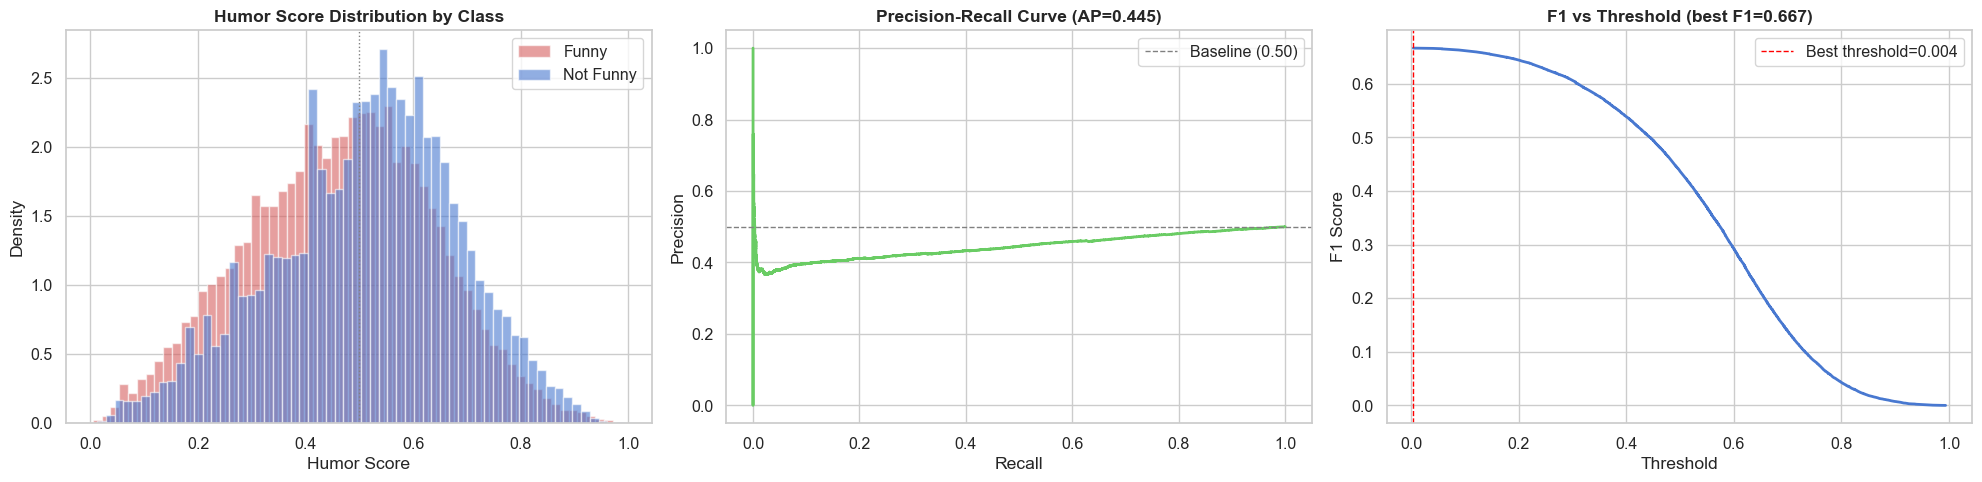


Best threshold: 0.0042  |  Best F1: 0.6667  |  AP: 0.4449


In [6]:
y_true = sample["label_is_funny_binary"].values
humor_scores = sample["humor_score"].values

# --- 1. Score distribution by class ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1a – Histogram of humor_score by class
for label, name, color in [(1, "Funny", sns.color_palette()[3]), (0, "Not Funny", sns.color_palette()[0])]:
    mask = y_true == label
    axes[0].hist(humor_scores[mask], bins=60, alpha=0.6, label=name, color=color, density=True)
axes[0].set_xlabel("Humor Score")
axes[0].set_ylabel("Density")
axes[0].set_title("Humor Score Distribution by Class", fontweight="bold")
axes[0].legend()
axes[0].axvline(0.5, color="grey", ls=":", lw=1)

# 1b – Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_true, humor_scores)
ap = average_precision_score(y_true, humor_scores)
axes[1].plot(recall, precision, color=sns.color_palette()[2], lw=2)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"Precision-Recall Curve (AP={ap:.3f})", fontweight="bold")
axes[1].axhline(y_true.mean(), color="grey", ls="--", lw=1, label=f"Baseline ({y_true.mean():.2f})")
axes[1].legend()

# 1c – F1 vs threshold
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
axes[2].plot(thresholds, f1_scores, color=sns.color_palette()[0], lw=2)
axes[2].axvline(best_threshold, color="red", ls="--", lw=1, label=f"Best threshold={best_threshold:.3f}")
axes[2].set_xlabel("Threshold")
axes[2].set_ylabel("F1 Score")
axes[2].set_title(f"F1 vs Threshold (best F1={f1_scores[best_idx]:.3f})", fontweight="bold")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nBest threshold: {best_threshold:.4f}  |  Best F1: {f1_scores[best_idx]:.4f}  |  AP: {ap:.4f}")

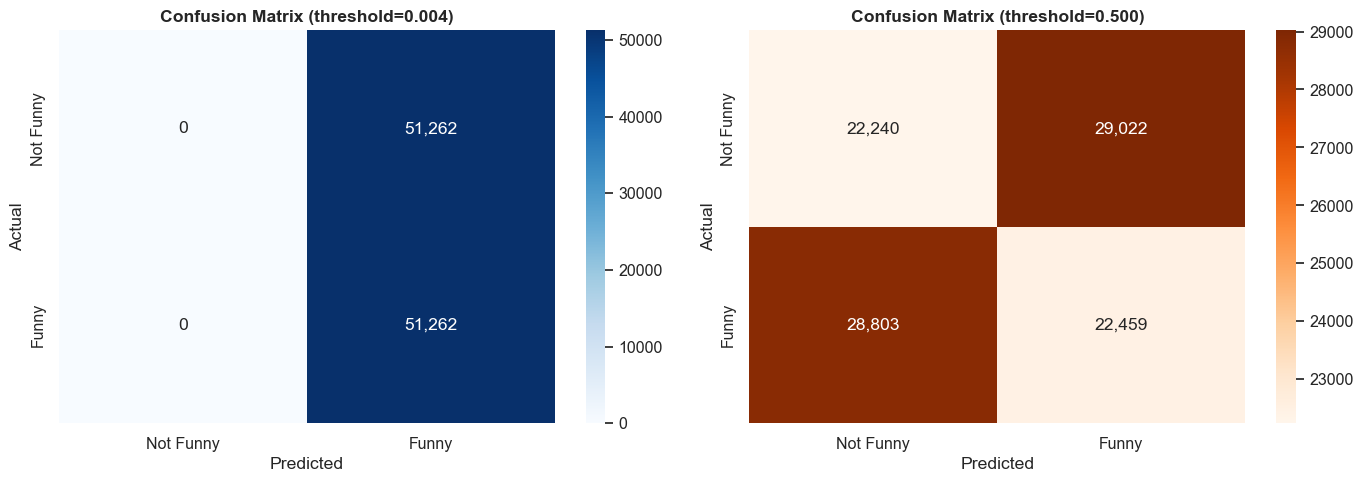

=== Best Threshold ===
              precision    recall  f1-score   support

   Not Funny       0.00      0.00      0.00     51262
       Funny       0.50      1.00      0.67     51262

    accuracy                           0.50    102524
   macro avg       0.25      0.50      0.33    102524
weighted avg       0.25      0.50      0.33    102524


=== Threshold = 0.5 ===
              precision    recall  f1-score   support

   Not Funny       0.44      0.43      0.43     51262
       Funny       0.44      0.44      0.44     51262

    accuracy                           0.44    102524
   macro avg       0.44      0.44      0.44    102524
weighted avg       0.44      0.44      0.44    102524

ROC AUC: 0.4192


e:\GitProjects\steamReviewHumor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\GitProjects\steamReviewHumor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\GitProjects\steamReviewHumor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [7]:
# --- Classification report at best threshold + confusion matrix ---
y_pred = (humor_scores >= best_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", ax=axes[0],
            xticklabels=["Not Funny", "Funny"], yticklabels=["Not Funny", "Funny"])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title(f"Confusion Matrix (threshold={best_threshold:.3f})", fontweight="bold")

# Also at 0.5 threshold for comparison
y_pred_05 = (humor_scores >= 0.5).astype(int)
cm_05 = confusion_matrix(y_true, y_pred_05)
sns.heatmap(cm_05, annot=True, fmt=",", cmap="Oranges", ax=axes[1],
            xticklabels=["Not Funny", "Funny"], yticklabels=["Not Funny", "Funny"])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix (threshold=0.500)", fontweight="bold")

plt.tight_layout()
plt.show()

print("=== Best Threshold ===")
print(classification_report(y_true, y_pred, target_names=["Not Funny", "Funny"]))

print("\n=== Threshold = 0.5 ===")
print(classification_report(y_true, y_pred_05, target_names=["Not Funny", "Funny"]))

# ROC AUC
try:
    roc = roc_auc_score(y_true, humor_scores)
    print(f"ROC AUC: {roc:.4f}")
except ValueError:
    print("ROC AUC: could not compute")

In [8]:
# --- Top predictions: most/least "funny" according to BERT vs actual labels ---
print("=" * 80)
print("TOP 10 reviews BERT thinks are MOST funny (highest humor_score)")
print("=" * 80)
for _, row in sample.nlargest(10, "humor_score").iterrows():
    label = "✓ FUNNY" if row["label_is_funny_binary"] == 1 else "✗ NOT FUNNY"
    print(f"\n[{label}]  humor_score={row['humor_score']:.4f}  votes_funny={row.get('review_votes_funny', '?')}")
    print(f"  {str(row['review_text_cleaned'])[:150]}...")

print("\n" + "=" * 80)
print("TOP 10 reviews BERT thinks are LEAST funny (lowest humor_score)")
print("=" * 80)
for _, row in sample.nsmallest(10, "humor_score").iterrows():
    label = "✓ FUNNY" if row["label_is_funny_binary"] == 1 else "✗ NOT FUNNY"
    print(f"\n[{label}]  humor_score={row['humor_score']:.4f}  votes_funny={row.get('review_votes_funny', '?')}")
    print(f"  {str(row['review_text_cleaned'])[:150]}...")

TOP 10 reviews BERT thinks are MOST funny (highest humor_score)

[✗ NOT FUNNY]  humor_score=0.9937  votes_funny=0
  TLDR: Game is amazing, but Easy Anti Cheat is a piece of garbage that can crash your PC when launching.

This is the best souls game that I've playe...

[✗ NOT FUNNY]  humor_score=0.9910  votes_funny=0
  What was supposed to be a "quick break from work" turned into a gleeful, 25-hour exploration of this game's captivating world, in only a couple of day...

[✗ NOT FUNNY]  humor_score=0.9885  votes_funny=0
  Original. Mischievous. Creative. Innovative. Artistic.
One of the most hilarious game experiences I've ever seen....

[✓ FUNNY]  humor_score=0.9874  votes_funny=1
  Edit 8/15/25: Phantom Liberty is literally the plot of the movie Escape from New York. Lmaooooo. Omg, dude. I'm Snake Plissken, bro! Is there anything...

[✓ FUNNY]  humor_score=0.9860  votes_funny=2
  A revolutionary, fun, yet emotional co-op experience that quickly became one of my top 10 favourite games o